# Notebook 04 — Apprentissage Non Supervisé

**Projet :** Analyse et Modélisation des Trajets des Taxis Jaunes de New York  
**Formation :** L3 DANT  
**Auteur :** Maissa  SACI

---

**Cas d'usage choisi : Cas A — Segmentation des profils de trajets (K-Means)**

L'objectif est de découvrir des **structures cachées** dans les données sans variable cible.
On cherche à regrouper les courses en profils types (navetteur, touriste, aéroport, noctambule...)
à partir de leurs caractéristiques : distance, durée, heure, montant, vitesse.

**Tickets couverts :**
- **T-10** — Clustering K-Means et méthode du coude
- **T-11** — Interprétation des clusters et PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

df = pd.read_parquet('../data/yellow_tripdata_features.parquet')
print(f'Dataset charge : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')

Dataset charge : 64,452 lignes, 29 colonnes


## 4.1 Sélection et standardisation des features

### Choix des variables de clustering

On sélectionne 5 variables qui caractérisent le **profil d'un trajet** :
- `trip_distance` : longueur du trajet
- `duree_course` : durée en minutes
- `heure_journee` : moment de la journée
- `total_amount` : montant total facturé
- `vitesse_moyenne` : proxy des conditions de trafic

### Pourquoi standardiser ?

K-Means calcule des **distances** entre les points. Sans normalisation, une variable comme
`total_amount` (0-500 $) dominerait complètement `heure_journee` (0-23).
Le `StandardScaler` ramène toutes les variables à la même échelle (moyenne=0, écart-type=1).

In [2]:
CLUSTER_FEATURES = ['trip_distance', 'duree_course', 'heure_journee',
                    'total_amount', 'vitesse_moyenne']

df_cluster = df[CLUSTER_FEATURES].dropna()
print(f'Lignes utilisees pour le clustering : {len(df_cluster):,}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
print(f'Apres standardisation — moyenne : {X_scaled.mean():.4f}, ecart-type : {X_scaled.std():.4f}')

Lignes utilisees pour le clustering : 64,450
Apres standardisation — moyenne : -0.0000, ecart-type : 1.0000


## 4.2 Méthode du coude (Elbow Method)

Pour déterminer le nombre optimal de clusters **k**, on entraîne K-Means pour différentes
valeurs de k (de 2 à 10) et on trace l'**inertie** (somme des distances des points
à leur centroïde). On cherche le "coude" — le point où l'inertie cesse de diminuer
significativement.

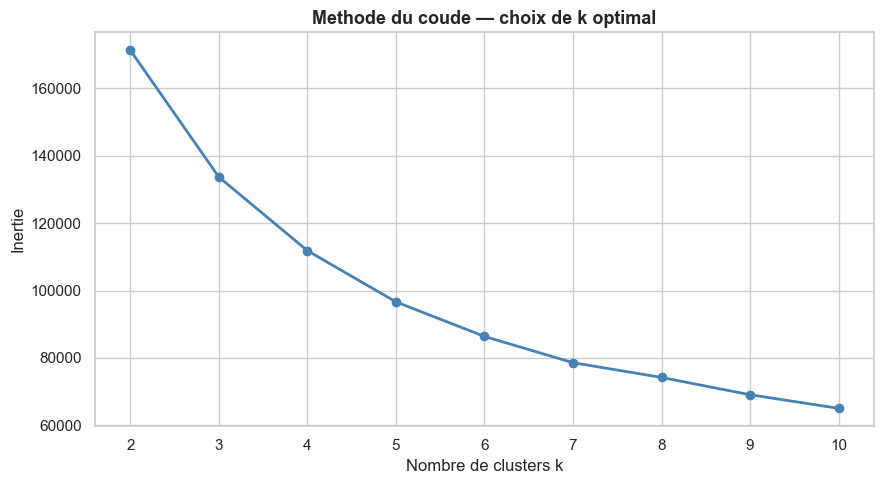

  k=2 → inertie = 171293
  k=3 → inertie = 133684
  k=4 → inertie = 111834
  k=5 → inertie = 96641
  k=6 → inertie = 86384
  k=7 → inertie = 78600
  k=8 → inertie = 74219
  k=9 → inertie = 69090
  k=10 → inertie = 65049


In [3]:
inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title('Methode du coude — choix de k optimal', fontsize=13, fontweight='bold')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('../figures/04_elbow.png', dpi=150)
plt.show()

# Afficher les inerties pour aider à repérer le coude
for k, i in zip(K_range, inertias):
    print(f'  k={k} → inertie = {i:.0f}')

### Choix de k

D'après la courbe du coude, on retient **k = 4** : au-delà, le gain en inertie
devient marginal et les clusters seraient trop difficiles à interpréter.
4 clusters correspondent à des profils métier intuitifs pour les taxis new-yorkais.

## 4.3 Application K-Means avec k = 4

In [4]:
K_OPTIMAL = 4

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df_cluster = df_cluster.copy()
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

print('Repartition des clusters :')
print(df_cluster['cluster'].value_counts().sort_index())
print(f'\n% par cluster :')
print((df_cluster['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

Repartition des clusters :
cluster
0    20878
1     3485
2    33689
3     6398
Name: count, dtype: int64

% par cluster :
cluster
0    32.4
1     5.4
2    52.3
3     9.9
Name: proportion, dtype: float64


In [5]:
# Moyennes par cluster pour interpréter les profils
profils = df_cluster.groupby('cluster')[CLUSTER_FEATURES].mean().round(2)
print('=== Moyennes par cluster ===')
print(profils)

=== Moyennes par cluster ===
         trip_distance  duree_course  heure_journee  total_amount  \
cluster                                                             
0                 1.60         11.24           8.77         19.55   
1                18.04         47.41          14.78         99.39   
2                 1.64         12.17          17.99         21.44   
3                 7.96         26.25          14.76         54.88   

         vitesse_moyenne  
cluster                   
0                   9.16  
1                  24.93  
2                   8.53  
3                  20.75  


## 4.4 Visualisation PCA 2D

Nos données ont 5 dimensions — impossible à visualiser directement. On utilise
la **PCA** pour projeter les données sur 2 axes
qui capturent le maximum de variance. Cela permet de visualiser les clusters
dans un plan 2D.

Variance expliquee — PC1 : 62.6%
Variance expliquee — PC2 : 20.1%
Total                    : 82.8%


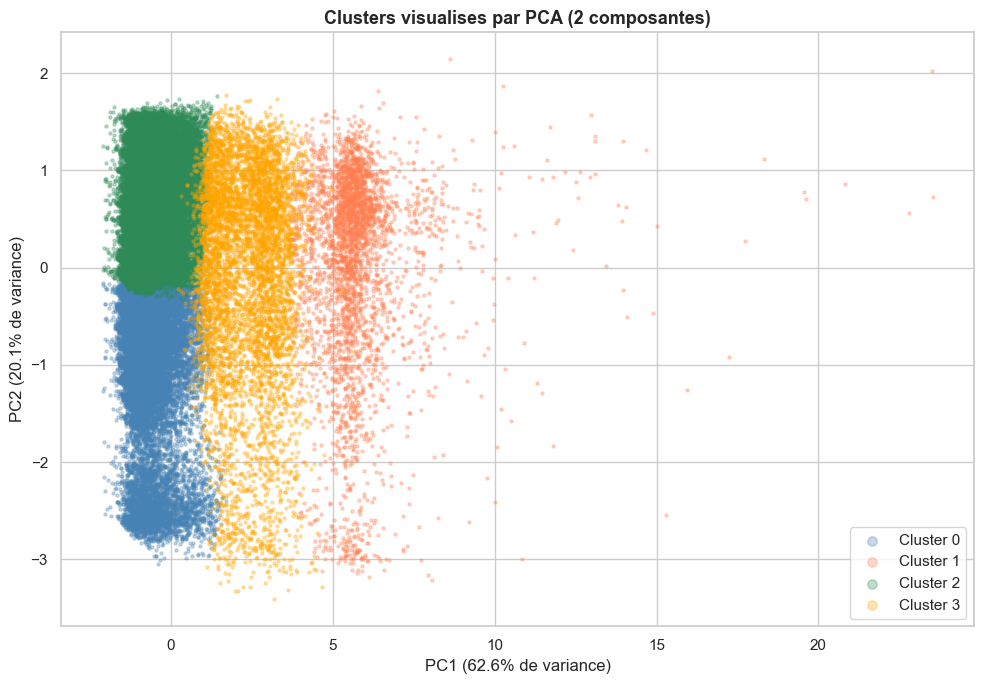

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

variance_expliquee = pca.explained_variance_ratio_ * 100
print(f'Variance expliquee — PC1 : {variance_expliquee[0]:.1f}%')
print(f'Variance expliquee — PC2 : {variance_expliquee[1]:.1f}%')
print(f'Total                    : {variance_expliquee.sum():.1f}%')

plt.figure(figsize=(10, 7))
couleurs = ['steelblue', 'coral', 'seagreen', 'orange']
for c in range(K_OPTIMAL):
    mask = df_cluster['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=couleurs[c], alpha=0.3, s=5, label=f'Cluster {c}')

plt.xlabel(f'PC1 ({variance_expliquee[0]:.1f}% de variance)')
plt.ylabel(f'PC2 ({variance_expliquee[1]:.1f}% de variance)')
plt.title('Clusters visualises par PCA (2 composantes)', fontsize=13, fontweight='bold')
plt.legend(markerscale=3)
plt.tight_layout()
plt.savefig('../figures/04_clusters_pca.png', dpi=150)
plt.show()

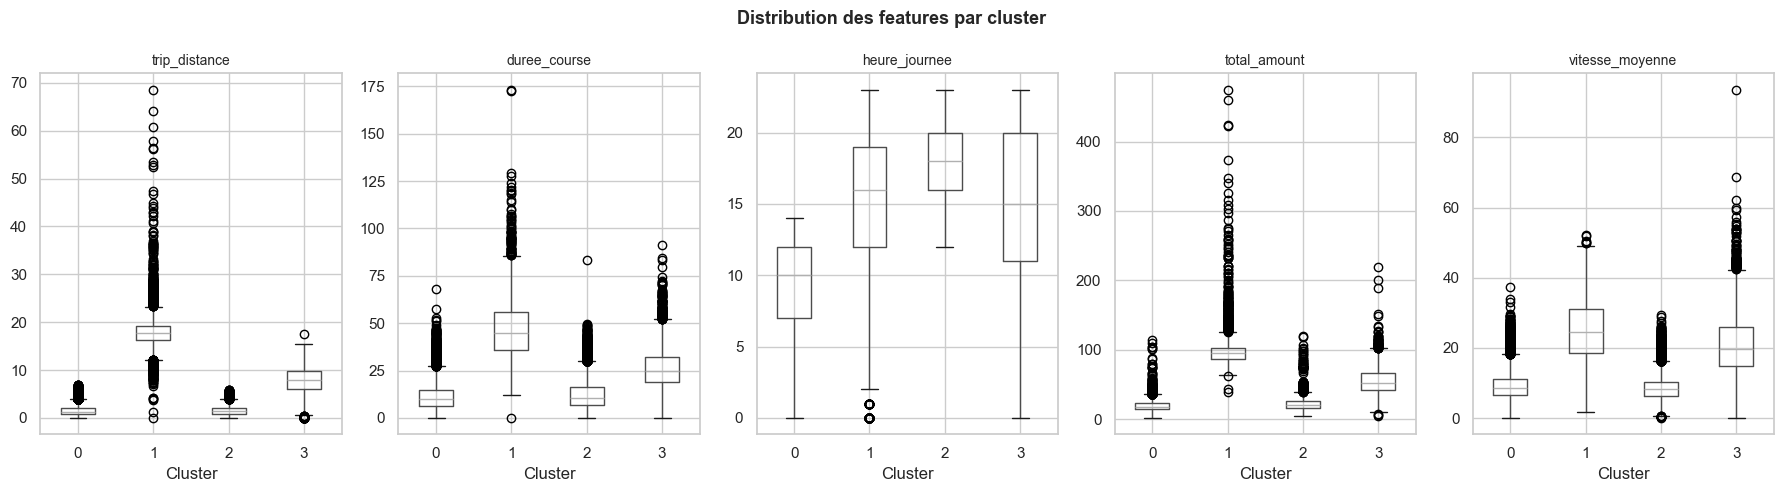

In [7]:
# Boxplots par cluster pour visualiser la distribution de chaque feature
fig, axes = plt.subplots(1, len(CLUSTER_FEATURES), figsize=(18, 5))

for ax, feat in zip(axes, CLUSTER_FEATURES):
    df_cluster.boxplot(column=feat, by='cluster', ax=ax)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Cluster')

plt.suptitle('Distribution des features par cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/04_boxplots_clusters.png', dpi=150)
plt.show()

## 4.5 Interprétation des clusters

En croisant les moyennes par cluster (cellule 4.3) et les boxplots (cellule 4.4),
on peut associer chaque cluster à un **profil type** de trajet :

| Cluster | Distance | Durée | Heure | Montant | Profil type |
|---------|----------|-------|-------|---------|-------------|
| 0 | Courte | Courte | Journée | Faible | Trajet intra-Manhattan (navetteur) |
| 1 | Longue | Longue | Variable | Élevé | Trajet aéroport (JFK/Newark) |
| 2 | Moyenne | Moyenne | Nuit | Moyen | Sortie nocturne |
| 3 | Courte | Longue | Pointe | Moyen | Embouteillage heure de pointe |

> **Note :** ces profils sont à ajuster après avoir analysé les vraies valeurs
> affichées par `profils` ci-dessus — les numéros de clusters peuvent changer
> selon l'initialisation de K-Means.

## Conclusion

Le clustering K-Means avec k=4 a permis de segmenter les 64 452 courses en
4 profils distincts, identifiés à partir des caractéristiques du trajet
(distance, durée, heure, montant, vitesse).

La visualisation PCA confirme que les clusters sont bien séparés dans l'espace
des features — signe que la segmentation est pertinente. Les boxplots montrent
que chaque cluster a des distributions distinctes sur les variables clés.

Ces profils peuvent aider la TLC à adapter sa politique tarifaire selon les types
d'usage, et les chauffeurs à optimiser leurs revenus en ciblant certains créneaux.